# Viktor prompt-complexity pipeline

This notebook builds and audits a leakage-safe training dataset from the proprietary Viktor challenge export. It does **not** embed raw data or generated outputs in the notebook.

The generated target is a transparent weak-supervision score, not measured model quality. The raw export has no final model output, usage, timing, or quality label.

## What the builder guarantees

- Every JSONL request becomes one ML example.
- Exact prefix-linked requests are reconstructed into chains.
- Exact, prefix-linked, and semantic near-duplicate task openings stay in one split.
- Normalization is fitted on training rows only; final scores retain their natural weighted distribution.
- Inputs contain only system/developer text, user text, and deterministic text features.
- Logged model and observed execution are target/audit metadata, never predictor inputs.
- Train, validation, and test files are aligned by `request_id`.

In [32]:
from pathlib import Path
import json
import statistics
import subprocess
import sys
from collections import Counter, defaultdict

ROOT = Path.cwd()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent

EXPORT_DIR = ROOT / 'export'
OUTPUT_DIR = ROOT / 'results' / 'complexity_dataset'
SEED = 42
ROOT, EXPORT_DIR, OUTPUT_DIR

(PosixPath('/Users/linuspummer/Documents/coding/vibe_coding/munich-ehl-2026'),
 PosixPath('/Users/linuspummer/Documents/coding/vibe_coding/munich-ehl-2026/export'),
 PosixPath('/Users/linuspummer/Documents/coding/vibe_coding/munich-ehl-2026/results/complexity_dataset'))

## 1. Build features, targets, metadata, and splits

The split is deterministic. Re-running with the same seed produces the same assignment. Near-duplicate prompt clusters are assigned atomically.

In [33]:
command = [
    sys.executable,
    str(ROOT / 'scripts' / 'build_complexity_dataset.py'),
    str(EXPORT_DIR),
    '--output-dir', str(OUTPUT_DIR),
    '--seed', str(SEED),
    '--train-ratio', '0.70',
    '--validation-ratio', '0.15',
    '--test-ratio', '0.15',
]
subprocess.run(command, cwd=ROOT, check=True)

requests=1000 trajectories=1000 split_groups=872
split request counts: {'train': 700, 'validation': 150, 'test': 150}
label confidence: {'train': {'high': 196, 'medium': 504}, 'validation': {'medium': 108, 'high': 42}, 'test': {'medium': 112, 'high': 38}}
split leakage: 0 prompt groups, 0 trajectories
wrote /Users/linuspummer/Documents/coding/vibe_coding/munich-ehl-2026/results/complexity_dataset


CompletedProcess(args=['/Users/linuspummer/Documents/coding/vibe_coding/munich-ehl-2026/.venv/bin/python', '/Users/linuspummer/Documents/coding/vibe_coding/munich-ehl-2026/scripts/build_complexity_dataset.py', '/Users/linuspummer/Documents/coding/vibe_coding/munich-ehl-2026/export', '--output-dir', '/Users/linuspummer/Documents/coding/vibe_coding/munich-ehl-2026/results/complexity_dataset', '--seed', '42', '--train-ratio', '0.70', '--validation-ratio', '0.15', '--test-ratio', '0.15'], returncode=0)

In [34]:
manifest = json.loads((OUTPUT_DIR / 'manifest.json').read_text())
summary_keys = [
    'request_count', 'trajectory_count', 'split_group_count',
    'split_request_counts', 'complexity_bands_by_split',
    'label_confidence_by_split', 'split_safety',
]
{key: manifest[key] for key in summary_keys}

{'request_count': 1000,
 'trajectory_count': 1000,
 'split_group_count': 872,
 'split_request_counts': {'train': 700, 'validation': 150, 'test': 150},
 'complexity_bands_by_split': {'train': {'medium': 479, 'high': 218, 'low': 3},
  'validation': {'medium': 102, 'high': 47, 'low': 1},
  'test': {'medium': 104, 'high': 44, 'low': 2}},
 'label_confidence_by_split': {'train': {'high': 196, 'medium': 504},
  'validation': {'medium': 108, 'high': 42},
  'test': {'medium': 112, 'high': 38}},
 'split_safety': {'strategy': 'exact-prefix grouping plus deterministic 64-value MinHash/LSH near-duplicate clusters',
  'same_opening_prompt_always_same_split': True,
  'exact_prefix_trajectory_always_same_split': True,
  'leaked_split_groups': 0,
  'leaked_trajectories': 0}}

## 2. Verify alignment and leakage invariants

These assertions deliberately fail if a request is duplicated, input/target order differs, or a prompt/trajectory appears in more than one split.

In [35]:
def read_jsonl(path):
    with Path(path).open() as handle:
        return [json.loads(line) for line in handle if line.strip()]

datasets = {}
group_splits = defaultdict(set)
trajectory_splits = defaultdict(set)
all_request_ids = set()

for split in ('train', 'validation', 'test'):
    inputs = read_jsonl(OUTPUT_DIR / f'{split}_inputs.jsonl')
    targets = read_jsonl(OUTPUT_DIR / f'{split}_targets.jsonl')
    metadata = read_jsonl(OUTPUT_DIR / f'{split}_metadata.jsonl')
    input_ids = [row['request_id'] for row in inputs]
    target_ids = [row['request_id'] for row in targets]
    metadata_ids = [row['request_id'] for row in metadata]
    assert input_ids == target_ids == metadata_ids
    assert not (all_request_ids & set(input_ids))
    all_request_ids.update(input_ids)
    for row in metadata:
        group_splits[row['split_group_id']].add(split)
        trajectory_splits[row['trajectory_id']].add(split)
    datasets[split] = (inputs, targets, metadata)

assert len(all_request_ids) == manifest['request_count']
assert all(len(splits) == 1 for splits in group_splits.values())
assert all(len(splits) == 1 for splits in trajectory_splits.values())
print('Verified: aligned files, unique requests, and zero group/trajectory leakage.')

Verified: aligned files, unique requests, and zero group/trajectory leakage.


## 3. Inspect score and confidence distributions

Only scores and audit metadata are displayed here; prompts are intentionally not printed.

In [36]:
for split, (_, targets, _) in datasets.items():
    scores = [row['complexity_score'] for row in targets]
    print({
        'split': split,
        'rows': len(scores),
        'score_min': round(min(scores), 2),
        'score_mean': round(sum(scores) / len(scores), 2),
        'score_max': round(max(scores), 2),
        'bands': dict(Counter(row['complexity_band'] for row in targets)),
        'confidence': dict(Counter(row['label_confidence'] for row in targets)),
    })

{'split': 'train', 'rows': 700, 'score_min': 27.22, 'score_mean': 64.98, 'score_max': 98.65, 'bands': {'medium': 479, 'high': 218, 'low': 3}, 'confidence': {'high': 196, 'medium': 504}}
{'split': 'validation', 'rows': 150, 'score_min': 31.09, 'score_mean': 66.22, 'score_max': 93.71, 'bands': {'medium': 102, 'high': 47, 'low': 1}, 'confidence': {'medium': 108, 'high': 42}}
{'split': 'test', 'rows': 150, 'score_min': 25.57, 'score_mean': 63.83, 'score_max': 93.2, 'bands': {'medium': 104, 'high': 44, 'low': 2}, 'confidence': {'medium': 112, 'high': 38}}


In [37]:
# Detect provider-schema extraction failures and inspect remaining family effects.
model_scores = defaultdict(list)
nonempty_zero_intrinsic = []
for inputs, targets, metadata in datasets.values():
    for model_input, target, audit in zip(inputs, targets, metadata):
        model_scores[audit['logged_model']].append(target['complexity_score'])
        if model_input['user_prompt'].strip() and target['intrinsic_complexity'] == 0:
            nonempty_zero_intrinsic.append(target['request_id'])
assert not nonempty_zero_intrinsic
for model, scores in sorted(model_scores.items(), key=lambda item: -len(item[1])):
    print({
        'model': model, 'rows': len(scores),
        'mean_score': round(statistics.mean(scores), 2),
        'median_score': round(statistics.median(scores), 2),
    })

{'model': 'claude-opus-5', 'rows': 331, 'mean_score': 63.84, 'median_score': 62.42}
{'model': 'claude-sonnet-5', 'rows': 281, 'mean_score': 65.91, 'median_score': 64.49}
{'model': 'gpt-5.6-terra', 'rows': 113, 'mean_score': 66.49, 'median_score': 66.1}
{'model': 'gpt-5.6-sol', 'rows': 112, 'mean_score': 65.99, 'median_score': 65.54}
{'model': 'claude-fable-5', 'rows': 71, 'mean_score': 65.08, 'median_score': 64.32}
{'model': 'claude-opus-4-8', 'rows': 69, 'mean_score': 61.76, 'median_score': 60.76}
{'model': 'gpt-5.6-luna', 'rows': 20, 'mean_score': 68.23, 'median_score': 66.95}
{'model': 'claude-opus-4-6', 'rows': 2, 'mean_score': 69.02, 'median_score': 69.02}
{'model': 'claude-sonnet-4-6', 'rows': 1, 'mean_score': 53.55, 'median_score': 53.55}


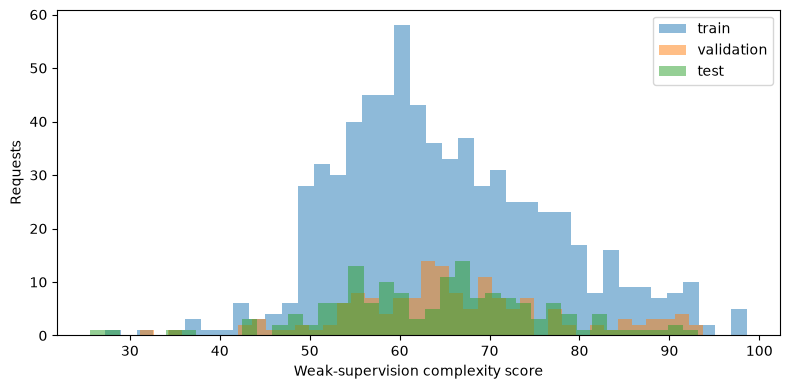

In [38]:
# Optional visualization; the data pipeline itself needs no third-party packages.
try:
    import matplotlib.pyplot as plt
except ImportError:
    print('Install matplotlib to display the histogram.')
else:
    plt.figure(figsize=(8, 4))
    for split, (_, targets, _) in datasets.items():
        plt.hist(
            [row['complexity_score'] for row in targets],
            bins=40, alpha=0.5, label=split,
        )
    plt.xlabel('Weak-supervision complexity score')
    plt.ylabel('Requests')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 4. Optional text-model baseline

This cell trains a simple TF–IDF ridge regressor on **user text only**. Validation is used during development; keep the test result for the final evaluation. A production router should also report downstream cost–quality performance, not only regression error.

In [39]:
try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import Ridge
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from sklearn.pipeline import make_pipeline
except ImportError:
    print('Install scikit-learn to run the optional model baseline.')
else:
    train_inputs, train_targets, _ = datasets['train']
    val_inputs, val_targets, _ = datasets['validation']
    test_inputs, test_targets, _ = datasets['test']

    X_train = [row['user_prompt'] for row in train_inputs]
    y_train = [row['complexity_score'] for row in train_targets]
    X_val = [row['user_prompt'] for row in val_inputs]
    y_val = [row['complexity_score'] for row in val_targets]
    X_test = [row['user_prompt'] for row in test_inputs]
    y_test = [row['complexity_score'] for row in test_targets]

    model = make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=30_000),
        Ridge(alpha=5.0),
    )
    model.fit(X_train, y_train)

    def evaluate(name, X, y):
        prediction = model.predict(X)
        return {
            'split': name,
            'MAE': round(mean_absolute_error(y, prediction), 3),
            'RMSE': round(mean_squared_error(y, prediction) ** 0.5, 3),
            'R2': round(r2_score(y, prediction), 3),
        }

    print(evaluate('validation', X_val, y_val))
    print(evaluate('test', X_test, y_test))

Install scikit-learn to run the optional model baseline.


## 5. Model catalog — turning benchmark evidence into quality cutoffs

Sections 1–4 produce a 0–100 complexity score per request. A router needs the other half of
the mapping: for each candidate model, the complexity above which it should not be trusted.
`scripts/model_catalog.py` derives those cutoffs from published benchmark results, so every
threshold traces to a citation rather than a hand-picked constant.

**The model ids in this export are not anonymised.** `AGENTS.md` says they are. But every id
is a real, publicly documented model, and `scripts/pricing.json` reproduces each one's public
list price to the cent — including `gpt-5.6-sol` / `terra` / `luna`, which read like
pseudonyms but are OpenAI's actual tier names. `AGENTS.md` says to trust a posted price sheet
over the briefing where the two conflict, so public benchmark data applies directly here.

The chain is kept short so each link can be argued with:

| step | what it does |
|---|---|
| benchmark panel | five agentic benchmarks, weighted by how well each proxies *this* workload |
| additive fit | joint model-ability / benchmark-difficulty estimate, on the logit scale |
| spread | rescale fitted ability across the catalog to 0–1 |
| quantile | map onto `[quantile_floor, 1]`, minus a margin that grows as evidence thins |
| cutoff | read that quantile off the **observed training** complexity distribution |

A benchmark score says nothing about this dataset's 0–100 scale, so the fit is used only to
**order and space** the models; the thresholds themselves come from the empirical
distribution. Calibration uses the training split only — calibrating on validation or test
would leak the evaluation set into the router, the invariant sections 1–2 exist to protect.

In [40]:
import importlib
import sys

if str(ROOT / 'scripts') not in sys.path:
    sys.path.insert(0, str(ROOT / 'scripts'))
import model_catalog

importlib.reload(model_catalog)

train_scores = [row['complexity_score'] for row in datasets['train'][1]]
catalog = model_catalog.build_catalog(train_scores, risk_aversion=0.10)

print(f"calibrated on {catalog['calibrated_on']['n_requests']} training requests "
      f"(scores {catalog['calibrated_on']['score_min']}–{catalog['calibrated_on']['score_max']})")
print(f"frontier / routing fallback: {catalog['frontier_model']}")
print(f"detectability band: {catalog['tie_band']:.2f} score points\n")

header = (f"{'model':<20}{'tier':>5}{'$in/M':>8}{'fitted':>8}{'evidence':>10}"
          f"{'cutoff':>8}   indistinguishable from")
print(header)
print('-' * (len(header) + 20))
for entry in catalog['models']:
    peers = ', '.join(entry['indistinguishable_from']) or '—'
    flag = '*' if entry['is_frontier'] else ('~' if entry['imputed'] else ' ')
    print(f"{entry['model_id']:<20}{entry['tier_group']:>5}"
          f"{entry['price_in_per_mtok']:>8.2f}{entry['expected_score']:>8.2f}"
          f"{entry['evidence_coverage']:>9.0%}{entry['complexity_cutoff']:>8.2f} {flag} {peers}")
print('\n* frontier (used when nothing else covers a request)   ~ imputed, no public evidence')
print('evidence = share of the weighted benchmark panel this model actually has results for')

calibrated on 700 training requests (scores 27.22–98.65)
frontier / routing fallback: gpt-5.6-sol
detectability band: 2.67 score points

model                tier   $in/M  fitted  evidence  cutoff   indistinguishable from
--------------------------------------------------------------------------------------------------------
gpt-5.6-terra           1    2.00   83.74      65%   85.48   gpt-5.6-sol, claude-fable-5, claude-opus-5, gpt-5.6-luna
gpt-5.6-sol             1    5.00   83.74      87%   86.41 * gpt-5.6-terra, claude-fable-5, claude-opus-5, gpt-5.6-luna
claude-fable-5          1   10.00   82.72     100%   82.85   gpt-5.6-terra, gpt-5.6-sol, claude-opus-5, gpt-5.6-luna
claude-opus-5           1    5.00   81.64      53%   77.50   gpt-5.6-terra, gpt-5.6-sol, claude-fable-5, gpt-5.6-luna
gpt-5.6-luna            1    0.20   81.13      65%   76.63   gpt-5.6-terra, gpt-5.6-sol, claude-fable-5, claude-opus-5
claude-sonnet-5         2    2.00   74.86      62%   65.78   —
claude-opus-4-8   

### 5.1 Which capability differences are real

Benchmark coverage in the public record is ragged — Opus 5 has no published SWE-bench Pro
result, the GPT-5.6 tiers have no SWE-bench Verified, `claude-opus-4-6` has nothing at all —
and the benchmarks also **disagree systematically about which family is stronger**. Those are
two different problems and they need two different fixes.

*Ragged coverage.* A naive composite (`score / best observed score`, averaged over whatever a
model happens to have) compares models on incomparable panels, so being measured only where
your family is strong is rewarded. Fix: compare every pair of models **only on the benchmarks
both were measured on**, then reconcile those pairwise differences into one ability by
weighted least squares.

*Systematic disagreement.* Least squares is still a global fit, so a model can be dragged down
through third parties. This is not hypothetical — it produced a live bug in an earlier version
of this notebook:

> `gpt-5.6-terra` was ranked **above** `gpt-5.6-sol`, even though Sol beats Terra on all three
> benchmarks they share (88.8 vs 87.4, 80.0 vs 77.4, 53.6 vs 50.4). The cause: Sol is unusually
> weak on SWE-bench Pro — 12 points below its own fit, the largest residual in the panel — and
> Terra was never measured on it. The penalty reached Terra's rival through models Terra never
> met.

Fix: **direct evidence outranks indirect inference.** Abilities are projected onto the partial
order of head-to-head dominance — if A beat B on every benchmark they share, A may not rank
below B — pooling any violating pair until none remain. Pooling equalises rather than
reorders, which is the smallest correction that removes the false claim.

Two things worth checking below: that the fitted difficulties rank **SWE-bench Verified as the
easiest** benchmark (everyone scores 88–97 on it) and **Agents' Last Exam as the hardest**; and
the **detectability band** from the fit's own residuals — the smallest gap in fitted score
worth believing.

In [41]:
cards = model_catalog._catalog_cards()
fit = model_catalog.fit_capability(cards)

print('fitted benchmark difficulty (logit; higher = everyone scores well = easier):')
for name, value in sorted(fit['difficulty'].items(), key=lambda kv: -kv[1]):
    print(f"  {model_catalog.BENCHMARKS[name]['label']:<24}{value:+7.3f}"
          f"   weight {model_catalog.BENCHMARKS[name]['weight']:.2f}")

print('\nhead-to-head dominance (A scored higher on every benchmark A and B both have):')
for winner, loser, shared in model_catalog.dominance_pairs(cards):
    print(f"  {winner:<20} > {loser:<20} on {shared} shared benchmarks")

repairs = fit['dominance_repaired']
print(f"\ndominance repairs applied: {len(repairs)}")
for repair in repairs:
    print(f"  {repair['winner']} had been ranked below {repair['loser']}"
          f"  ->  pooled {', '.join(repair['pooled_members'])}")
violations = [(w, l) for w, l, _ in model_catalog.dominance_pairs(cards)
              if fit['models'][w]['ability'] < fit['models'][l]['ability'] - 1e-12]
print(f"violations remaining after repair: {len(violations)}")

print('\nnaive composite vs fitted ability (rank shown as naive -> fitted):')
naive = model_catalog.naive_composite(cards)
naive_rank = {m: i + 1 for i, m in enumerate(
    sorted((k for k, v in naive.items() if v is not None), key=lambda k: -naive[k]))}
fit_rank = {m['model_id']: i + 1 for i, m in enumerate(catalog['models'])}

print(f"  {'model':<20}{'naive':>8}{'fitted':>8}{'rank':>10}{'benchmarks':>12}")
for entry in catalog['models']:
    mid = entry['model_id']
    value = naive.get(mid)
    moved = f"{naive_rank.get(mid, '-')} -> {fit_rank[mid]}"
    print(f"  {mid:<20}{'n/a' if value is None else f'{value:.3f}':>8}"
          f"{entry['expected_score']:>8.2f}{moved:>10}{entry['n_benchmarks']:>12}")

print(f"\nDetectability band: {catalog['tie_band']:.2f} score points.")
for tier in sorted({e['tier_group'] for e in catalog['models']}):
    members = [e for e in catalog['models'] if e['tier_group'] == tier]
    span = max(m['expected_score'] for m in members) - min(m['expected_score'] for m in members)
    cheapest = min(members, key=lambda m: m['price_in_per_mtok'])
    print(f"  tier {tier}: {', '.join(m['model_id'] for m in members)}")
    print(f"          spread {span:.2f} pts | prices "
          f"${min(m['price_in_per_mtok'] for m in members):.2f}–"
          f"${max(m['price_in_per_mtok'] for m in members):.2f}/M"
          f" | cheapest: {cheapest['model_id']}")

fitted benchmark difficulty (logit; higher = everyone scores well = easier):
  SWE-bench Verified       +1.511   weight 0.13
  Terminal-Bench 2.1       +0.269   weight 0.40
  AA Coding Agent Index    -0.347   weight 0.15
  SWE-bench Pro            -0.405   weight 0.22
  Agents' Last Exam        -1.629   weight 0.10

head-to-head dominance (A scored higher on every benchmark A and B both have):
  claude-fable-5       > claude-opus-4-8      on 3 shared benchmarks
  claude-fable-5       > claude-sonnet-5      on 2 shared benchmarks
  claude-fable-5       > claude-sonnet-4-6    on 2 shared benchmarks
  claude-opus-5        > claude-opus-4-8      on 2 shared benchmarks
  claude-opus-4-8      > claude-sonnet-4-6    on 2 shared benchmarks
  claude-sonnet-5      > claude-sonnet-4-6    on 2 shared benchmarks
  gpt-5.6-sol          > claude-sonnet-5      on 2 shared benchmarks
  gpt-5.6-sol          > claude-sonnet-4-6    on 2 shared benchmarks
  gpt-5.6-sol          > gpt-5.6-terra        on 3 

### 5.2 Cutoffs against the distribution they were calibrated on

The cutoffs only mean something relative to the complexity distribution they were read off.
Plotting them together shows how much of the observed workload each model is trusted with —
and makes it obvious when a cutoff sits somewhere the distribution is thin, where small
changes in the fit move a lot of traffic.

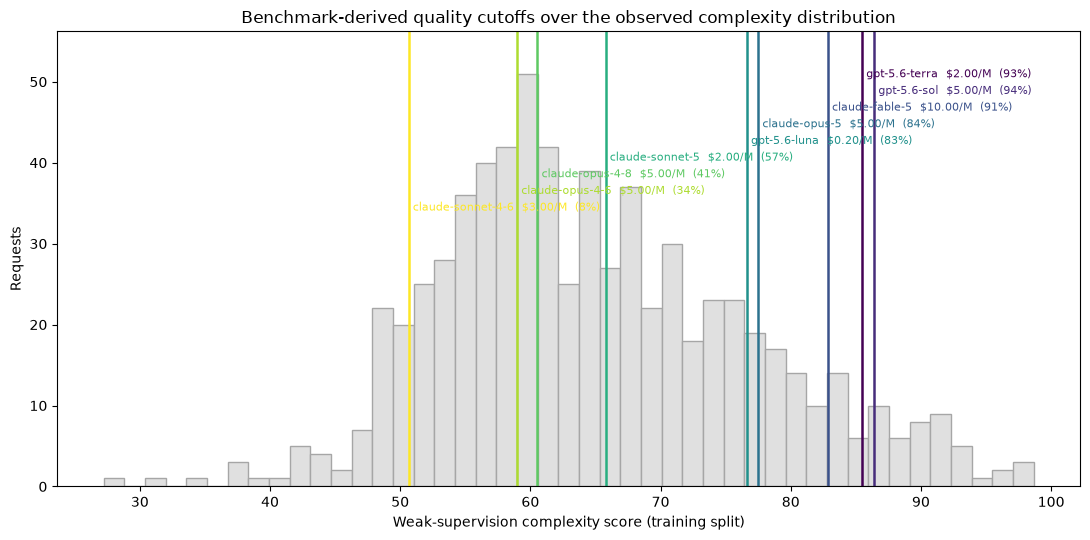

Percentage after each label = share of training requests at or below that cutoff.


In [42]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    print('Install matplotlib to display the cutoff chart.')
    for entry in catalog['models']:
        share = sum(1 for s in train_scores if s <= entry['complexity_cutoff']) / len(train_scores)
        print(f"  {entry['model_id']:<20} cutoff {entry['complexity_cutoff']:>6.2f}"
              f"   trusted with {share:>6.1%} of training requests")
else:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.hist(train_scores, bins=45, color='0.88', edgecolor='0.65', label='training requests')
    top = ax.get_ylim()[1]
    ax.set_ylim(0, top * 1.05)
    colours = plt.cm.viridis(
        [i / max(len(catalog['models']) - 1, 1) for i in range(len(catalog['models']))])

    for position, (colour, entry) in enumerate(zip(colours, catalog['models'])):
        share = sum(1 for s in train_scores
                    if s <= entry['complexity_cutoff']) / len(train_scores)
        ax.axvline(entry['complexity_cutoff'], color=colour, linewidth=1.8)
        ax.annotate(
            f"{entry['model_id']}  ${entry['price_in_per_mtok']:.2f}/M  ({share:.0%})",
            xy=(entry['complexity_cutoff'], top),
            xytext=(3, -11 - 12 * position), textcoords='offset points',
            fontsize=8, color=colour, va='top',
        )

    ax.set_xlabel('Weak-supervision complexity score (training split)')
    ax.set_ylabel('Requests')
    ax.set_title('Benchmark-derived quality cutoffs over the observed complexity distribution')
    plt.tight_layout()
    plt.show()

    print('Percentage after each label = share of training requests at or below that cutoff.')

### 5.3 The logged policy is not complexity-aware — which is where the headroom is

Before trusting any cutoff, it is worth asking what the *logged* assignment already does. If
Viktor were routing by difficulty, hard requests would sit on strong models and the correlation
between a request's complexity and its serving model's fitted capability would be clearly
positive.

It is not. That single fact carries most of the routing argument in this notebook, and it cuts
two ways:

- **In favour of a router:** there is real headroom, because the current assignment leaves
  complexity on the table. Any complexity-aware policy is competing against a policy that
  ignores complexity.
- **Against over-claiming:** because the logged data contains almost no complexity-driven
  model assignment, it also contains almost no evidence about which model a hard request
  *needs*. The observational log can tell us the current policy is undifferentiated; it cannot
  tell us the cutoffs are correct.

In [43]:
import statistics


def pearson(xs, ys):
    mx, my = statistics.mean(xs), statistics.mean(ys)
    numerator = sum((x - mx) * (y - my) for x, y in zip(xs, ys))
    denominator = (sum((x - mx) ** 2 for x in xs) * sum((y - my) ** 2 for y in ys)) ** 0.5
    return numerator / denominator if denominator else 0.0


capability = {m['model_id']: m['expected_score'] for m in catalog['models']}
price = {m['model_id']: m['price_in_per_mtok'] for m in catalog['models']}

scores = [t['complexity_score'] for t in datasets['train'][1]]
served = [m['logged_model'] for m in datasets['train'][2]]

print(f"corr(complexity, fitted capability of the model that served it) = "
      f"{pearson(scores, [capability[m] for m in served]):+.3f}")
print(f"corr(complexity, input price of the model that served it)       = "
      f"{pearson(scores, [price[m] for m in served]):+.3f}")

grouped = {}
for score, model in zip(scores, served):
    grouped.setdefault(model, []).append(score)

between = statistics.pstdev([statistics.mean(v) for v in grouped.values()])
within = statistics.mean([statistics.pstdev(v) for v in grouped.values() if len(v) > 1])
print(f"\nspread of per-model mean complexity : {between:>5.1f}")
print(f"typical spread *within* one model    : {within:>5.1f}")
print(f"overall complexity range             : {min(scores):.1f}–{max(scores):.1f}")
print('\nWithin-model variation swamps between-model variation: whatever decided which')
print('model served a request, it was almost entirely something other than difficulty.')

corr(complexity, fitted capability of the model that served it) = +0.032
corr(complexity, input price of the model that served it)       = -0.092

spread of per-model mean complexity :   4.8
typical spread *within* one model    :  11.1
overall complexity range             : 27.2–98.6

Within-model variation swamps between-model variation: whatever decided which
model served a request, it was almost entirely something other than difficulty.


### 5.4 Sweeping risk aversion

`risk_aversion` is the single knob that turns this catalog into a cost–quality frontier. It is
the maximum quantile a model can be demoted by: `0.0` trusts the benchmarks completely, higher
values pull every cutoff down so more work escalates to stronger models.

Routing is done **per trajectory, on its hardest call**. That respects the export's
one-model-per-trajectory premise and avoids the cache-reset penalty `scripts/cost_model.py`
charges for a mid-trajectory switch.

The price index below is *token-weighted* using the estimated prompt tokens already in
`static_text_features`, comparing the routed model's input rate against the logged model's.
It is a **unit-price comparison, not a cost estimate**: it excludes output tokens (there are
no outputs in the export), excludes the tool-call history that dominates long trajectories,
and ignores cache effects entirely.

In [44]:
from collections import defaultdict

train_inputs, train_targets, train_meta = datasets['train']
by_trajectory = defaultdict(list)
for inp, tgt, meta in zip(train_inputs, train_targets, train_meta):
    features = inp['static_text_features']
    by_trajectory[meta['trajectory_id']].append((
        tgt['complexity_score'],
        features['system_est_tokens'] + features['user_est_tokens'],
        meta['logged_model'],
    ))

CLAUDE_ONLY = [m['model_id'] for m in catalog['models'] if m['family'] == 'claude']


def sweep(allowed=None, snap=False):
    rows = []
    for risk in (0.0, 0.05, 0.10, 0.20, 0.30):
        swept = model_catalog.build_catalog(train_scores, risk_aversion=risk,
                                            snap_to_band=snap)
        prices = {m['model_id']: m['price_in_per_mtok'] for m in swept['models']}
        mix, routed, logged_cost, fallbacks = defaultdict(int), 0.0, 0.0, 0
        for calls in by_trajectory.values():
            choice, reason = model_catalog.route_trajectory(
                [c[0] for c in calls], swept, allowed=allowed)
            mix[choice] += 1
            fallbacks += reason == 'fallback_frontier'
            for _, tokens, logged in calls:
                routed += tokens * prices[choice]
                logged_cost += tokens * prices[logged]
        rows.append((risk, routed / logged_cost, fallbacks / len(by_trajectory), mix))
    return rows


def show(title, rows):
    print(f'\n{title}')
    print(f"{'risk':>6}{'index':>8}{'fallback':>10}   route mix (trajectories)")
    print('-' * 96)
    for risk, index, fallback, mix in rows:
        share = ', '.join(f'{m} {n}/{len(by_trajectory)}'
                          for m, n in sorted(mix.items(), key=lambda kv: -kv[1]))
        print(f'{risk:>6.2f}{index:>7.2f}x{fallback:>9.0%}   {share}')


logged_claude = sum(1 for c in by_trajectory.values() if c[0][2].startswith('claude'))
print(f'{len(by_trajectory)} training trajectories; logged mix is {logged_claude}/{len(by_trajectory)} Claude')

show('All nine catalogued models available:', sweep())
show(f'Claude family only ({len(CLAUDE_ONLY)} models):', sweep(CLAUDE_ONLY))
show('Claude family only, ties resolved on price (snap_to_band=True):',
     sweep(CLAUDE_ONLY, snap=True))

print()
print("index 1.00x = the logged models' blended input rate; lower is cheaper")
print('fallback = trajectories above every cutoff, escalated to the frontier model')
print()
print('Read the three tables together:')
print()
print('  * Unconstrained is the least trustworthy. It is driven almost entirely by')
print('    gpt-5.6-luna, the cheapest and least-corroborated model here (see 5.5).')
print()
print('  * Claude-only WITHOUT snapping is worse than the logged policy above risk')
print('    0.05 -- and that is a flaw in the routing rule, not a finding. Opus 5 and')
print('    Fable 5 sit in the same detectability band, so escalating to Fable at')
print('    $10/M instead of Opus 5 at $5/M pays double for a capability difference')
print('    the benchmarks cannot actually measure.')
print()
print('  * Snapping fixes exactly that: within a tier the ordering is noise, so')
print('    members share the tier cutoff and the router separates them on price')
print('    alone. This is the defensible Claude-only number.')

700 training trajectories; logged mix is 527/700 Claude

All nine catalogued models available:
  risk   index  fallback   route mix (trajectories)
------------------------------------------------------------------------------------------------
  0.00   0.11x       0%   gpt-5.6-luna 626/700, gpt-5.6-terra 74/700
  0.05   0.13x       3%   gpt-5.6-luna 603/700, gpt-5.6-terra 93/700, gpt-5.6-sol 4/700
  0.10   0.15x       6%   gpt-5.6-luna 579/700, gpt-5.6-terra 113/700, gpt-5.6-sol 8/700
  0.20   0.19x      11%   gpt-5.6-luna 532/700, gpt-5.6-terra 152/700, gpt-5.6-sol 16/700
  0.30   0.23x      17%   gpt-5.6-luna 485/700, gpt-5.6-terra 192/700, gpt-5.6-sol 23/700

Claude family only (6 models):
  risk   index  fallback   route mix (trajectories)
------------------------------------------------------------------------------------------------
  0.00   0.93x       4%   claude-sonnet-5 450/700, claude-opus-5 190/700, claude-fable-5 60/700
  0.05   1.00x       7%   claude-sonnet-5 427/700, cl

### 5.5 What this catalog gets wrong

The catalog is deliberately auditable, which means its assumptions are visible rather than
absent. Four are load-bearing enough to state before anything else.

**The benchmarks cannot resolve the top of the catalog.** Luna, Terra, Sol, Fable 5 and Opus 5
all fall inside one detectability band — a 2.6-point spread across a **50× price range**
($0.20 → $10.00/M). Taken at face value that says: take the cheapest and save 50× for no
measurable capability loss. Taken sceptically it says these benchmarks are saturated and
simply cannot separate the models this workload most depends on. **Both readings fit the
evidence, and this catalog cannot distinguish them.** Only the trajectories can.

**A single capability number is a simplification the data actively resists.** The benchmarks
disagree about which family is stronger, and not randomly: Sol is 12 points below its own fit
on SWE-bench Pro while Fable 5 is 8 points below its own fit on Agents' Last Exam. Those are
model×benchmark interactions, and collapsing them into one scalar hides them by construction.
The dominance repair in §5.1 stops that from producing an outright false ordering; it does not
make the scalar true.

**The cheapest model is suspiciously competitive.** Luna scores within ~2.6 points of the
frontier at 1/25th of Sol's input price, on three numbers that all trace to a single secondary
source. OpenAI positions Luna as a low-reasoning tier for high-volume work, which directly
contradicts what its agentic benchmark scores imply. A router that trusts these numbers sends
almost everything to Luna. That is the most consequential and least verified claim here, and
it is why §5.4 reports the Claude-only sweep alongside the unconstrained one.

**A cutoff assumes failures are the hardest tasks.** Mapping a benchmark success rate onto a
complexity ceiling only works if a model fails the hard things first. Models fail
idiosyncratically, so a cutoff is a central tendency, not a guarantee.

In [45]:
print('Recorded limitations (scripts/model_catalog.py):\n')
for i, item in enumerate(catalog['limitations'], 1):
    print(f"{i:>2}. {item}\n")

print('Benchmarks deliberately excluded from the panel:\n')
for name, reason in catalog['excluded_benchmarks'].items():
    print(f"  - {name}: {reason}\n")

worst = max(catalog['models'], key=lambda m: m['max_source_disagreement'])
top_tier = [m['model_id'] for m in catalog['models'] if m['tier_group'] == 1]
print(f"Largest single-model source disagreement: {worst['model_id']} spans "
      f"{worst['max_source_disagreement']:.1f} benchmark points across published sources —\n"
      f"wider than the {catalog['tie_band']:.2f}-point band that holds the top "
      f"{len(top_tier)} models ({', '.join(top_tier)})\nin a single indistinguishable tier.")

Recorded limitations (scripts/model_catalog.py):

 1. Benchmark scores are a frozen manual transcription (2026-08-22), not a live feed. Re-check them before reusing this catalog.

 2. Published benchmarks measure end-to-end task success on THEIR task distribution. Treating that as a ceiling on THIS dataset's complexity score assumes a model's failures are the hardest tasks. Models actually fail idiosyncratically, so a cutoff is a central tendency, not a guarantee.

 3. The complexity score is itself weak supervision, not measured quality. The cutoffs inherit every assumption baked into its weights.

 4. Harness and effort settings move scores more than model identity does at the top of the range: Opus 5's Terminal-Bench result spans 81.3-89.1 depending on refusal handling and effort. Any cutoff derived from a single number is over-precise.

 5. Coverage is ragged. Opus 5 has no public SWE-bench Pro or AA-index result, the GPT-5.6 tiers have no SWE-bench Verified, and claude-opus-4-6 ha

## Files produced

For each split, `*_inputs.jsonl` contains predictor-safe text/features, `*_targets.jsonl` contains the score and its components, and `*_metadata.jsonl` contains audit-only identifiers and the logged model. `all.jsonl` combines them for analysis, while `manifest.json` records formulas, scaling caps, split counts, and limitations.

Before using this score as a router target, manually review a stratified sample from the low/medium/high bands. The score is deliberately auditable, but its weights still encode assumptions that should be validated against human or judge-model ratings.